<a href="https://colab.research.google.com/github/tishamondal-stargazer/Machine-Learning/blob/main/Practical-07-Extra-SVM-Regression/Practical-07-Extra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS23059 Tisha Mondal


ML Lab-7 Extra Practical

Aim: To apply Support Vector Machine for Regression on Students Performance Dataset and analyze the impact of different kernels on model accuracy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
url = "https://raw.githubusercontent.com/tishamondal-stargazer/Machine-Learning/refs/heads/main/datasets/Student_Performance_dataset_5000%20(1).csv"
df = pd.read_csv(url)

df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [4]:
df.shape

(5000, 21)

In [5]:
df.columns


Index(['student_id', 'age', 'gender', 'academic_level', 'study_hours',
       'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'internet_quality', 'mental_health_score', 'focus_index',
       'burnout_level', 'productivity_score', 'exam_score'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality     

In [7]:
df.describe()

,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,20.520400,4.539594,2.478734,2.011984,2.998086,1.564514,7.016492,6.979588,74.535600,251.450400,0.498200,0.501400,5.507400,29.431616,45.615324,37.267716,18.803752
std,1443.520003,2.870406,1.821665,1.177990,0.983906,1.467949,1.110807,1.163692,2.486214,42.932293,143.842712,0.500047,0.500048,2.869145,9.962902,14.246591,16.849397,12.130840
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1250.750000,18.000000,3.250000,1.660000,1.320000,1.990000,0.670000,6.237500,5.280000,37.000000,129.000000,0.000000,0.000000,3.000000,22.567500,35.727500,25.290000,9.337500
50%,2500.500000,20.000000,4.530000,2.480000,2.010000,2.980000,1.490000,7.010000,6.950000,75.000000,252.000000,0.000000,1.000000,5.000000,29.430000,45.690000,36.860000,18.010000
75%,3750.250000,23.000000,5.760000,3.290000,2.690000,4.030000,2.340000,7.810000,8.710000,112.000000,376.000000,1.000000,1.000000,8.000000,36.242500,55.352500,49.142500,27.400000
max,5000.000000,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,149.000000,499.000000,1.000000,1.000000,10.000000,63.480000,97.580000,98.020000,64.090000


In [8]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
academic_level,0
study_hours,0
self_study_hours,0
online_classes_hours,0
social_media_hours,0
gaming_hours,0
sleep_hours,0


In [9]:
df = df.dropna()

In [10]:
# Drop student_id (not useful for prediction)
df = df.drop(columns=['student_id'])

# Define Features and Target
X = df.drop(columns=['exam_score'])
y = df['exam_score']

In [11]:
X = pd.get_dummies(X, dtype=int)

In [12]:
print(X.shape)
print(y.shape)

(5000, 25)
(5000,)


In [13]:
X = pd.get_dummies(X, dtype=int)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.7,
    test_size=0.3,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (3500, 25)
Testing shape: (1500, 25)


In [15]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [16]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train, y_train)

y_pred_linear = svr_linear.predict(X_test)

print("Linear Kernel")
print("MSE:", mean_squared_error(y_test, y_pred_linear))
print("R2 Score:", r2_score(y_test, y_pred_linear))
print("--------------------------------")

Linear Kernel
MSE: 25.627546145770943
R2 Score: 0.8189910418865811
--------------------------------


In [17]:
svr_rbf = SVR(kernel='rbf')
svr_rbf.fit(X_train, y_train)

y_pred_rbf = svr_rbf.predict(X_test)

print("RBF Kernel")
print("MSE:", mean_squared_error(y_test, y_pred_rbf))
print("R2 Score:", r2_score(y_test, y_pred_rbf))
print("--------------------------------")

RBF Kernel
MSE: 28.48638445375326
R2 Score: 0.7987988884670074
--------------------------------


In [18]:
svr_poly = SVR(kernel='poly')
svr_poly.fit(X_train, y_train)

y_pred_poly = svr_poly.predict(X_test)

print("Polynomial Kernel")
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("R2 Score:", r2_score(y_test, y_pred_poly))
print("--------------------------------")

Polynomial Kernel
MSE: 32.666749827333845
R2 Score: 0.7692727068926509
--------------------------------


In [19]:
svr_sigmoid = SVR(kernel='sigmoid')
svr_sigmoid.fit(X_train, y_train)

y_pred_sigmoid = svr_sigmoid.predict(X_test)

print("Sigmoid Kernel")
print("MSE:", mean_squared_error(y_test, y_pred_sigmoid))
print("R2 Score:", r2_score(y_test, y_pred_sigmoid))
print("--------------------------------")

Sigmoid Kernel
MSE: 28.21381255530689
R2 Score: 0.8007240807998253
--------------------------------


In [20]:
# Create a dictionary to store results

results = {
    "Linear": r2_score(y_test, y_pred_linear),
    "RBF": r2_score(y_test, y_pred_rbf),
    "Polynomial": r2_score(y_test, y_pred_poly),
    "Sigmoid": r2_score(y_test, y_pred_sigmoid)
}

print("R2 Score Comparison:")
for kernel, score in results.items():
    print(f"{kernel} Kernel : {score:.4f}")

R2 Score Comparison:
Linear Kernel : 0.8190
RBF Kernel : 0.7988
Polynomial Kernel : 0.7693
Sigmoid Kernel : 0.8007


In [21]:
mse_results = {
    "Linear": mean_squared_error(y_test, y_pred_linear),
    "RBF": mean_squared_error(y_test, y_pred_rbf),
    "Polynomial": mean_squared_error(y_test, y_pred_poly),
    "Sigmoid": mean_squared_error(y_test, y_pred_sigmoid)
}

print("\nMSE Comparison:")
for kernel, score in mse_results.items():
    print(f"{kernel} Kernel : {score:.4f}")


MSE Comparison:
Linear Kernel : 25.6275
RBF Kernel : 28.4864
Polynomial Kernel : 32.6667
Sigmoid Kernel : 28.2138


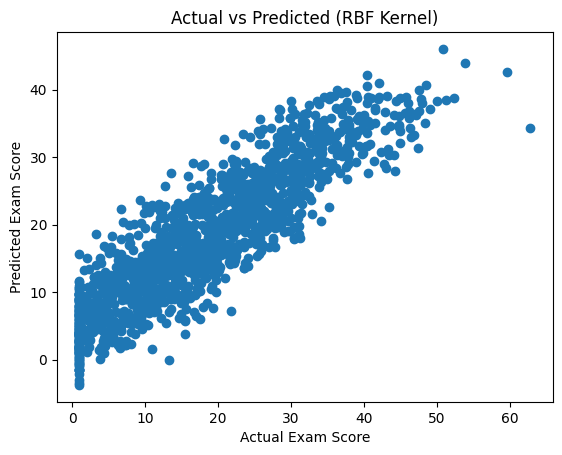

In [22]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rbf)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted (RBF Kernel)")
plt.show()